# Lab 18 — Training Large Language Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-18-training-large-language-models.ipynb)

This lab accompanies **Chapter 18: Training Large Language Models** in *The Mathematics of Natural Language Processing*.

The chapter explains a central idea:

$$
\text{LLM training} = \text{empirical risk minimization over token sequences}.
$$

Pretraining, supervised fine-tuning, instruction tuning, preference tuning, and alignment are not mysterious separate topics.  They differ mainly in

1. the data distribution;
2. the loss function;
3. the masking rule;
4. the regularization or constraint relative to a reference model;
5. the subset of parameters being updated.

This notebook is designed for independent study.  It introduces the background before each programming task and uses a tiny transparent model so that every quantity can be inspected.

## Learning goals

By the end of this lab, you should be able to:

1. write autoregressive pretraining as maximum likelihood estimation;
2. construct teacher-forced input-target pairs from token sequences;
3. compute token-level cross-entropy, negative log-likelihood, and perplexity;
4. explain why padding masks and response masks matter;
5. verify the gradient formula for softmax cross-entropy;
6. train a tiny next-token model using AdamW;
7. compare pretraining and supervised fine-tuning losses;
8. measure distributional movement using KL divergence;
9. compute a Bradley--Terry preference loss and a DPO-style objective;
10. interpret low-rank adaptation as a parameter-efficient update.

## 1. Mathematical background: pretraining as maximum likelihood

Let $V$ be a finite vocabulary and let

$$
w_{1:T}=(w_1,w_2,\ldots,w_T)
$$

be a token sequence.  An autoregressive language model defines

$$
p_\theta(w_{1:T})=\prod_{t=1}^T p_\theta(w_t\mid w_{<t}).
$$

Given a corpus $D=\{w^{(1)}_{1:T_1},\ldots,w^{(N)}_{1:T_N}\}$, maximum likelihood chooses

$$
\widehat \theta
=
\arg\max_\theta
\prod_{i=1}^N p_\theta(w^{(i)}_{1:T_i}).
$$

Equivalently, we minimize negative log-likelihood:

$$
L_{\text{pre}}(\theta)
=
-
\frac{1}{M}
\sum_{i=1}^N\sum_{t=1}^{T_i}
\log p_\theta(w_t^{(i)}\mid w_{<t}^{(i)}),
$$

where $M$ is the number of predicted tokens.  This is the token-level cross-entropy training objective.

## 2. Setup

We use only standard scientific Python libraries.  The model in this notebook is intentionally tiny: it predicts the next token from the previous token.  This is not a modern Transformer, but the training losses, masks, KL penalties, and preference objectives are the same mathematical objects used in large language model training.

In [1]:
import math
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(2026)

## 3. Data for pretraining, supervised fine-tuning, and preference learning

We use three small datasets:

- **pretraining data**: ordinary short text sequences;
- **supervised fine-tuning data**: prompt-response examples;
- **preference data**: a prompt with a preferred response and a less preferred response.

A real LLM pipeline uses huge datasets.  Here we use small text so that the notebook remains fully inspectable.

In [2]:
pretrain_corpus = [
    "language models predict the next token",
    "probability models assign likelihood to text",
    "attention models use context for prediction",
    "transformers use causal masks for generation",
    "students study probability linear algebra and optimization",
    "vectors represent documents and words",
    "retrieval systems compare queries and documents",
    "language generation samples one token at a time",
    "neural models map prefixes to logits",
    "optimization trains neural models from examples",
    "causal masks prevent future information leakage",
    "mathematics explains why algorithms work",
    "data quality shapes model behavior",
    "validation loss helps detect overfitting",
    "cross entropy measures prediction error",
]

sft_examples = [
    ("explain perplexity", "perplexity is exponential average negative log likelihood"),
    ("define causal mask", "a causal mask blocks attention to future tokens"),
    ("why use validation data", "validation data estimates performance on unseen examples"),
    ("explain supervised fine tuning", "supervised fine tuning trains on prompt response examples"),
    ("what is cross entropy", "cross entropy penalizes low probability on the correct token"),
]

preference_examples = [
    {
        "prompt": "explain model training",
        "chosen": "model training minimizes loss on examples while checking validation performance",
        "rejected": "model training is magic and always works",
    },
    {
        "prompt": "explain safe evaluation",
        "chosen": "safe evaluation tests behavior with clear metrics and human review",
        "rejected": "safe evaluation means trusting the model completely",
    },
]

print("Pretraining sentences:", len(pretrain_corpus))
print("SFT examples:", len(sft_examples))
print("Preference examples:", len(preference_examples))

Pretraining sentences: 15
SFT examples: 5
Preference examples: 2


## 4. Tokenization and vocabulary

We use a simple educational tokenizer:

1. lowercase the text;
2. keep alphabetic tokens;
3. add special tokens for padding, sequence boundaries, and chat roles.

Special tokens:

- `<pad>`: fills unused positions in a batch;
- `<bos>`: beginning of sequence;
- `<eos>`: end of sequence;
- `<unk>`: unknown token;
- `<user>`: start of the prompt;
- `<assistant>`: start of the response.

In [3]:
def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>", "<user>", "<assistant>"]

all_texts = list(pretrain_corpus)
for prompt, response in sft_examples:
    all_texts.extend([prompt, response])
for item in preference_examples:
    all_texts.extend([item["prompt"], item["chosen"], item["rejected"]])

word_counts = Counter(tok for text in all_texts for tok in tokenize(text))
vocab = special_tokens + sorted(word_counts)
stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

pad_id = stoi["<pad>"]
bos_id = stoi["<bos>"]
eos_id = stoi["<eos>"]
unk_id = stoi["<unk>"]
user_id = stoi["<user>"]
assistant_id = stoi["<assistant>"]

print("Vocabulary size:", len(vocab))
print("First 25 tokens:", vocab[:25])

Vocabulary size: 117
First 25 tokens: ['<pad>', '<bos>', '<eos>', '<unk>', '<user>', '<assistant>', 'a', 'algebra', 'algorithms', 'always', 'and', 'assign', 'at', 'attention', 'average', 'behavior', 'blocks', 'causal', 'checking', 'clear', 'compare', 'completely', 'context', 'correct', 'cross']


## 5. Encode sequences

For pretraining, every token after `<bos>` is a prediction target:

$$
\langle \text{bos}\rangle, w_1,w_2,\ldots,w_T,\langle \text{eos}\rangle.
$$

For supervised fine-tuning, a common masking rule is to train only on the assistant response, not on the prompt.  The sequence is

$$
\langle \text{bos}\rangle, \langle \text{user}\rangle, \text{prompt}, \langle \text{assistant}\rangle, \text{response}, \langle \text{eos}\rangle.
$$

The response mask is 1 only when the target token belongs to the response or the final `<eos>`.

In [4]:
def ids_from_words(words):
    return [stoi.get(w, unk_id) for w in words]

def encode_pretrain(text):
    return [bos_id] + ids_from_words(tokenize(text)) + [eos_id]

def encode_chat(prompt, response):
    prompt_ids = ids_from_words(tokenize(prompt))
    response_ids = ids_from_words(tokenize(response))
    return [bos_id, user_id] + prompt_ids + [assistant_id] + response_ids + [eos_id]

def response_loss_mask_for_chat(prompt, response):
    ids = encode_chat(prompt, response)
    assistant_pos = ids.index(assistant_id)
    # For next-token pairs, target at position t is predicted from previous token at t-1.
    # We train only when the target position is after <assistant>.
    return np.array([1.0 if t > assistant_pos else 0.0 for t in range(1, len(ids))])

pretrain_sequences = [encode_pretrain(text) for text in pretrain_corpus]
sft_sequences = [encode_chat(prompt, response) for prompt, response in sft_examples]
sft_masks = [response_loss_mask_for_chat(prompt, response) for prompt, response in sft_examples]

print("Example pretraining sequence:")
print([itos[i] for i in pretrain_sequences[0]])

print("\nExample SFT sequence:")
print([itos[i] for i in sft_sequences[0]])
print("SFT loss mask for next-token targets:", sft_masks[0].astype(int).tolist())

Example pretraining sequence:
['<bos>', 'language', 'models', 'predict', 'the', 'next', 'token', '<eos>']

Example SFT sequence:
['<bos>', '<user>', 'explain', 'perplexity', '<assistant>', 'perplexity', 'is', 'exponential', 'average', 'negative', 'log', 'likelihood', '<eos>']
SFT loss mask for next-token targets: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]


## 6. Batching, padding, and masks

Neural networks train on batches.  Sentences have different lengths, so we pad them to a common length.  Padding creates fake tokens, so the loss must ignore them.

For a batch of sequences, we create:

- `prev_ids`: tokens used as contexts;
- `target_ids`: next-token labels;
- `loss_mask`: 1 for real targets included in the objective, 0 otherwise.

In [5]:
def make_batch(sequences, loss_masks=None):
    max_pairs = max(len(seq) - 1 for seq in sequences)
    prev = np.full((len(sequences), max_pairs), pad_id, dtype=int)
    target = np.full((len(sequences), max_pairs), pad_id, dtype=int)
    mask = np.zeros((len(sequences), max_pairs), dtype=float)

    for i, seq in enumerate(sequences):
        n_pairs = len(seq) - 1
        prev[i, :n_pairs] = seq[:-1]
        target[i, :n_pairs] = seq[1:]
        if loss_masks is None:
            mask[i, :n_pairs] = 1.0
        else:
            mask[i, :n_pairs] = loss_masks[i]
    return prev, target, mask

pre_prev, pre_target, pre_mask = make_batch(pretrain_sequences)
sft_prev, sft_target, sft_mask = make_batch(sft_sequences, sft_masks)

print("Pretraining batch shapes:")
print("prev:", pre_prev.shape, "target:", pre_target.shape, "mask:", pre_mask.shape)

example_table = pd.DataFrame({
    "previous_token": [itos[i] for i in sft_prev[0]],
    "target_token": [itos[i] for i in sft_target[0]],
    "loss_mask": sft_mask[0].astype(int),
})
example_table

Pretraining batch shapes:
prev: (15, 9) target: (15, 9) mask: (15, 9)


,previous_token,target_token,loss_mask
0,<bos>,<user>,0
1,<user>,explain,0
2,explain,perplexity,0
3,perplexity,<assistant>,0
4,<assistant>,perplexity,1
5,perplexity,is,1
6,is,exponential,1
7,exponential,average,1
8,average,negative,1
9,negative,log,1


### Interpretation

The prompt tokens are part of the input context, but their prediction loss is masked out.  This is important for instruction tuning because we usually want the model to learn how to answer, not to memorize the user prompt distribution.

## 7. Softmax cross-entropy and its gradient

For logits $z\in R^{|V|}$ and correct class $y$, softmax gives

$$
p_j=\frac{e^{z_j}}{\sum_k e^{z_k}}.
$$

The token-level cross-entropy loss is

$$
\ell(z,y)=-\log p_y.
$$

A key formula for neural network training is

$$
\frac{\partial \ell}{\partial z_j}=p_j-1_{j=y}.
$$

The next cell verifies the formula numerically.

In [6]:
def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

def ce_single(z, y):
    p = softmax(z)
    return -np.log(p[y] + 1e-12)

z = np.array([0.2, -1.0, 1.3, 0.7])
y = 2
p = softmax(z)
analytic_grad = p.copy()
analytic_grad[y] -= 1.0

# Finite-difference gradient check.
eps = 1e-5
numeric_grad = np.zeros_like(z)
for j in range(len(z)):
    step = np.zeros_like(z)
    step[j] = eps
    numeric_grad[j] = (ce_single(z + step, y) - ce_single(z - step, y)) / (2 * eps)

pd.DataFrame({
    "probability": p,
    "analytic_gradient": analytic_grad,
    "numeric_gradient": numeric_grad,
    "absolute_error": np.abs(analytic_grad - numeric_grad),
})

,probability,analytic_gradient,numeric_gradient,absolute_error
0,0.167952,0.167952,0.167952,1.283557e-12
1,0.050586,0.050586,0.050586,9.152623e-12
2,0.504556,-0.495444,-0.495444,4.177492e-12
3,0.276906,0.276906,0.276906,9.062695e-12


## 8. A tiny next-token model

To focus on training objectives rather than architecture, we use a bigram neural model:

$$
\text{logits}(w_t\mid w_{t-1}) = W_{w_{t-1},:}.
$$

The parameter matrix $W\in R^{|V|\times |V|}$ stores one logit vector for each previous token.  This model is small, but the same loss calculation appears inside large Transformer training.

In [7]:
def softmax_rows(Z):
    Z = np.asarray(Z, dtype=float)
    Z_shifted = Z - Z.max(axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

def loss_and_grad(W, prev_ids, target_ids, loss_mask, ref_W=None, beta_kl=0.0):
    active = (loss_mask.reshape(-1) > 0) & (target_ids.reshape(-1) != pad_id)
    rows = prev_ids.reshape(-1)[active]
    targets = target_ids.reshape(-1)[active]
    n = len(targets)
    if n == 0:
        return 0.0, np.zeros_like(W), {"ce": 0.0, "kl": 0.0, "active_tokens": 0}

    logits = W[rows]
    probs = softmax_rows(logits)
    ce = -np.log(probs[np.arange(n), targets] + 1e-12).mean()

    dlogits = probs.copy()
    dlogits[np.arange(n), targets] -= 1.0
    dlogits /= n

    grad = np.zeros_like(W)
    np.add.at(grad, rows, dlogits)

    kl_value = 0.0
    if ref_W is not None and beta_kl > 0:
        q = softmax_rows(ref_W[rows])
        log_ratio = np.log(probs + 1e-12) - np.log(q + 1e-12)
        kl_each = np.sum(probs * log_ratio, axis=1)
        kl_value = kl_each.mean()
        # Gradient of KL(softmax(z) || q) with respect to z.
        dkl = probs * (log_ratio - kl_each[:, None])
        dkl /= n
        np.add.at(grad, rows, beta_kl * dkl)

    loss = ce + beta_kl * kl_value
    return loss, grad, {"ce": ce, "kl": kl_value, "active_tokens": n}

def perplexity_from_ce(ce):
    return float(np.exp(ce))

# Initialize small random weights.
V = len(vocab)
W0 = rng.normal(0.0, 0.02, size=(V, V))
initial_loss, _, initial_info = loss_and_grad(W0, pre_prev, pre_target, pre_mask)
print("Initial pretraining cross-entropy:", round(initial_info["ce"], 4))
print("Initial perplexity:", round(perplexity_from_ce(initial_info["ce"]), 2))
print("Vocabulary size:", V)

Initial pretraining cross-entropy: 4.7647
Initial perplexity: 117.3
Vocabulary size: 117


## 9. Train with AdamW

AdamW is a widely used optimizer for Transformer training.  The update combines adaptive moment estimates with decoupled weight decay.

For this tiny model, full-batch training is enough.  In real LLM training, gradients are estimated from mini-batches distributed across many accelerators.

In [8]:
def train_adamw(W_init, prev_ids, target_ids, loss_mask, *, epochs=250, lr=0.25, weight_decay=0.01,
                ref_W=None, beta_kl=0.0, print_every=0):
    W = W_init.copy()
    m = np.zeros_like(W)
    v = np.zeros_like(W)
    beta1 = 0.9
    beta2 = 0.999
    eps = 1e-8
    history = []

    for t in range(1, epochs + 1):
        loss, grad, info = loss_and_grad(W, prev_ids, target_ids, loss_mask, ref_W=ref_W, beta_kl=beta_kl)
        # Decoupled weight decay.
        W *= (1.0 - lr * weight_decay)
        m = beta1 * m + (1.0 - beta1) * grad
        v = beta2 * v + (1.0 - beta2) * (grad * grad)
        m_hat = m / (1.0 - beta1 ** t)
        v_hat = v / (1.0 - beta2 ** t)
        W -= lr * m_hat / (np.sqrt(v_hat) + eps)

        if t == 1 or t % 5 == 0 or t == epochs:
            history.append({
                "epoch": t,
                "loss": loss,
                "cross_entropy": info["ce"],
                "kl": info["kl"],
                "perplexity": perplexity_from_ce(info["ce"]),
                "active_tokens": info["active_tokens"],
            })
        if print_every and t % print_every == 0:
            print(f"epoch {t:4d} | loss {loss:.4f} | ce {info['ce']:.4f} | ppl {perplexity_from_ce(info['ce']):.2f}")
    return W, pd.DataFrame(history)

W_pre, pre_history = train_adamw(W0, pre_prev, pre_target, pre_mask, epochs=250, lr=0.20, weight_decay=0.005)
pre_history.tail()

,epoch,loss,cross_entropy,kl,perplexity,active_tokens
46,230,0.644257,0.644257,0.0,1.904572,103
47,235,0.644202,0.644202,0.0,1.904467,103
48,240,0.644148,0.644148,0.0,1.904363,103
49,245,0.644094,0.644094,0.0,1.904261,103
50,250,0.644040,0.644040,0.0,1.904159,103


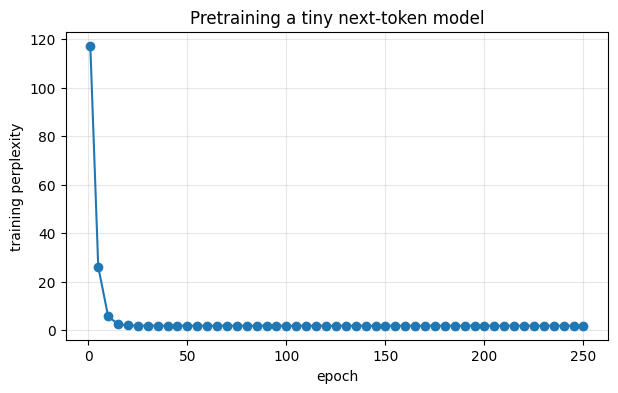

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(pre_history["epoch"], pre_history["perplexity"], marker="o")
plt.xlabel("epoch")
plt.ylabel("training perplexity")
plt.title("Pretraining a tiny next-token model")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Inspect learned next-token probabilities

Because the model is tiny, we can inspect conditional distributions directly.  This is often useful when teaching language-model objectives: logits are not labels; after softmax they become probabilities over the vocabulary.

In [10]:
def next_token_table(W, context_token, top_n=8):
    row = stoi.get(context_token, unk_id)
    probs = softmax_rows(W[[row]])[0]
    order = np.argsort(-probs)[:top_n]
    return pd.DataFrame({
        "next_token": [itos[i] for i in order],
        "probability": probs[order],
    })

for context in ["models", "causal", "validation", "language"]:
    print(f"\nTop next tokens after '{context}':")
    display(next_token_table(W_pre, context, top_n=6))


Top next tokens after 'models':


,next_token,probability
0,map,0.199229
1,use,0.199221
2,from,0.199217
3,assign,0.199216
4,predict,0.199215
5,study,0.000036



Top next tokens after 'causal':


,next_token,probability
0,masks,0.994421
1,review,0.000050
2,with,0.000050
3,shapes,0.000050
4,metrics,0.000050
5,evaluation,0.000050



Top next tokens after 'validation':


,next_token,probability
0,loss,0.994434
1,leakage,0.000050
2,behavior,0.000050
3,completely,0.000050
4,supervised,0.000050
5,at,0.000050



Top next tokens after 'language':


,next_token,probability
0,generation,0.497607
1,models,0.497541
2,examples,0.000044
3,from,0.000044
4,work,0.000044
5,validation,0.000044


## 11. Validation loss and overfitting

A training loss alone does not tell us whether the model generalizes.  We split the tiny pretraining corpus into a training part and a validation part.  With so little data, the validation curve is noisy, but the principle is the same as in large-scale training.

In [11]:
train_sequences = pretrain_sequences[:11]
val_sequences = pretrain_sequences[11:]
train_prev, train_target, train_mask = make_batch(train_sequences)
val_prev, val_target, val_mask = make_batch(val_sequences)

W_split = rng.normal(0.0, 0.02, size=(V, V))
m = np.zeros_like(W_split)
v = np.zeros_like(W_split)
lr = 0.20
weight_decay = 0.005
records = []

for t in range(1, 351):
    train_loss, grad, train_info = loss_and_grad(W_split, train_prev, train_target, train_mask)
    W_split *= (1.0 - lr * weight_decay)
    m = 0.9 * m + 0.1 * grad
    v = 0.999 * v + 0.001 * (grad * grad)
    m_hat = m / (1.0 - 0.9 ** t)
    v_hat = v / (1.0 - 0.999 ** t)
    W_split -= lr * m_hat / (np.sqrt(v_hat) + 1e-8)

    if t % 10 == 0 or t == 1:
        val_loss, _, val_info = loss_and_grad(W_split, val_prev, val_target, val_mask)
        records.append({
            "epoch": t,
            "train_ce": train_info["ce"],
            "val_ce": val_info["ce"],
            "train_ppl": perplexity_from_ce(train_info["ce"]),
            "val_ppl": perplexity_from_ce(val_info["ce"]),
        })

split_history = pd.DataFrame(records)
best_row = split_history.loc[split_history["val_ce"].idxmin()]
print("Best validation epoch:", int(best_row["epoch"]))
print("Best validation perplexity:", round(best_row["val_ppl"], 2))
split_history.tail()

Best validation epoch: 1
Best validation perplexity: 118.84


,epoch,train_ce,val_ce,train_ppl,val_ppl
31,310,0.639768,5.952398,1.896041,384.674657
32,320,0.639682,5.956622,1.895879,386.302971
33,330,0.639600,5.960751,1.895723,387.901338
34,340,0.639521,5.964786,1.895573,389.469615
35,350,0.639445,5.968728,1.895429,391.007902


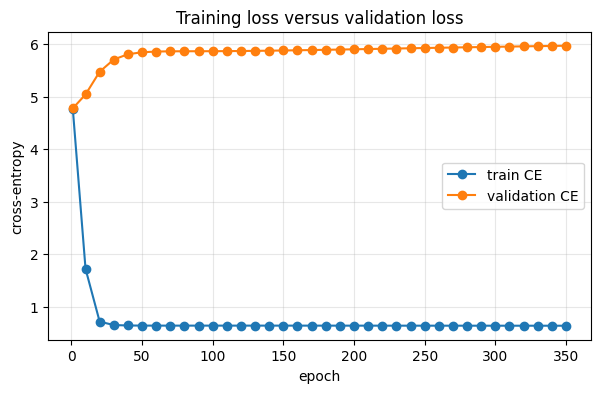

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(split_history["epoch"], split_history["train_ce"], marker="o", label="train CE")
plt.plot(split_history["epoch"], split_history["val_ce"], marker="o", label="validation CE")
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.title("Training loss versus validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Supervised fine-tuning with response-only loss

Supervised fine-tuning trains a pretrained model on prompt-response examples.  The most important implementation detail in this lab is the **response mask**:

$$
L_{\text{SFT}}(\theta)
=
-
\frac{1}{M_{\text{resp}}}
\sum_{(x,y)}\sum_{t\in \text{response positions}}
\log p_\theta(y_t\mid x,y_{<t}).
$$

The model conditions on the prompt, but the loss is only charged to the assistant response.

In [13]:
sft_loss_before, _, sft_info_before = loss_and_grad(W_pre, sft_prev, sft_target, sft_mask)
print("SFT response CE before fine-tuning:", round(sft_info_before["ce"], 4))
print("SFT response perplexity before fine-tuning:", round(perplexity_from_ce(sft_info_before["ce"]), 2))

W_sft, sft_history = train_adamw(W_pre, sft_prev, sft_target, sft_mask,
                                epochs=180, lr=0.15, weight_decay=0.003)

sft_loss_after, _, sft_info_after = loss_and_grad(W_sft, sft_prev, sft_target, sft_mask)
print("SFT response CE after fine-tuning:", round(sft_info_after["ce"], 4))
print("SFT response perplexity after fine-tuning:", round(perplexity_from_ce(sft_info_after["ce"]), 2))
sft_history.tail()

SFT response CE before fine-tuning: 5.7636
SFT response perplexity before fine-tuning: 318.49
SFT response CE after fine-tuning: 0.2646
SFT response perplexity after fine-tuning: 1.3


,epoch,loss,cross_entropy,kl,perplexity,active_tokens
32,160,0.265258,0.265258,0.0,1.303767,44
33,165,0.265082,0.265082,0.0,1.303538,44
34,170,0.264913,0.264913,0.0,1.303318,44
35,175,0.264751,0.264751,0.0,1.303107,44
36,180,0.264595,0.264595,0.0,1.302903,44


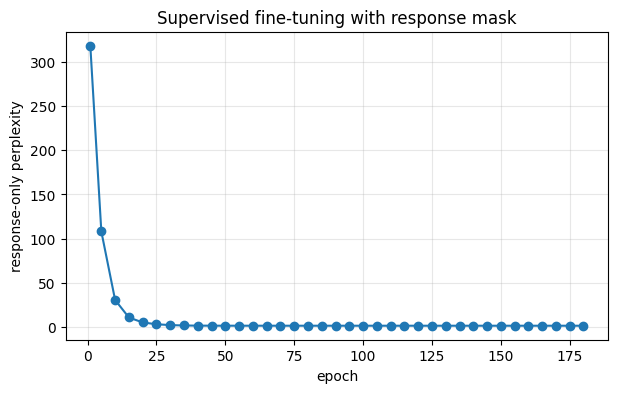

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(sft_history["epoch"], sft_history["perplexity"], marker="o")
plt.xlabel("epoch")
plt.ylabel("response-only perplexity")
plt.title("Supervised fine-tuning with response mask")
plt.grid(True, alpha=0.3)
plt.show()

## 13. Distributional movement and KL regularization

Fine-tuning can move the model away from its pretrained behavior.  A common mathematical tool is a KL penalty relative to a reference model:

$$
\mathrm{KL}(p_\theta(\cdot\mid c)\,\|\,p_{\text{ref}}(\cdot\mid c))
=
\sum_{w\in V}p_\theta(w\mid c)
\log\frac{p_\theta(w\mid c)}{p_{\text{ref}}(w\mid c)}.
$$

This penalty discourages the fine-tuned model from changing too much unless the supervised data gives a strong reason.

In [15]:
def average_kl_on_contexts(W, W_ref, contexts):
    rows = np.array([stoi.get(tok, unk_id) for tok in contexts], dtype=int)
    p = softmax_rows(W[rows])
    q = softmax_rows(W_ref[rows])
    kl_each = np.sum(p * (np.log(p + 1e-12) - np.log(q + 1e-12)), axis=1)
    return pd.DataFrame({"context": contexts, "KL(current || reference)": kl_each})

important_contexts = ["cross", "causal", "validation", "fine", "model", "training", "assistant"]
kl_sft = average_kl_on_contexts(W_sft, W_pre, important_contexts)
kl_sft

,context,KL(current || reference)
0,cross,5.462249e-03
1,causal,9.822564e+00
2,validation,9.786349e+00
3,fine,4.665658e+00
4,model,2.810973e-03
5,training,6.959219e-07
6,assistant,8.108586e-07


In [16]:
W_sft_kl, sft_kl_history = train_adamw(W_pre, sft_prev, sft_target, sft_mask,
                                      epochs=180, lr=0.15, weight_decay=0.003,
                                      ref_W=W_pre, beta_kl=0.30)

plain_loss, _, plain_info = loss_and_grad(W_sft, sft_prev, sft_target, sft_mask)
kl_loss, _, kl_info = loss_and_grad(W_sft_kl, sft_prev, sft_target, sft_mask)

summary = pd.DataFrame([
    {"model": "SFT without KL penalty", "response_CE": plain_info["ce"], "response_ppl": perplexity_from_ce(plain_info["ce"]),
     "mean_KL_on_contexts": average_kl_on_contexts(W_sft, W_pre, important_contexts)["KL(current || reference)"].mean()},
    {"model": "SFT with KL penalty", "response_CE": kl_info["ce"], "response_ppl": perplexity_from_ce(kl_info["ce"]),
     "mean_KL_on_contexts": average_kl_on_contexts(W_sft_kl, W_pre, important_contexts)["KL(current || reference)"].mean()},
])
summary

,model,response_CE,response_ppl,mean_KL_on_contexts
0,SFT without KL penalty,0.264565,1.302864,3.468978
1,SFT with KL penalty,0.803623,2.233618,1.160580


### Interpretation

KL-regularized fine-tuning usually trades off task fitting and staying close to the reference model.  In real systems, this is one way to reduce destructive distributional shifts during alignment or domain adaptation.

## 14. Preference learning: Bradley--Terry and DPO-style losses

Preference data often has the form

$$
(x,y^+,y^-),
$$

where $y^+$ is preferred to $y^-$ for prompt $x$.

A simple Bradley--Terry model says

$$
P(y^+\succ y^-\mid x)
=
\sigma(r(x,y^+)-r(x,y^-)),
$$

where $r$ is a reward score.

DPO-style objectives replace explicit reward learning with log-probability differences relative to a reference model.  A simplified DPO loss for one example is

$$
-
\log\sigma\left(
\beta
\left[
\log p_\theta(y^+\mid x)-\log p_\theta(y^-\mid x)
-
\log p_{\text{ref}}(y^+\mid x)+\log p_{\text{ref}}(y^-\mid x)
\right]
\right).
$$

In [17]:
def log_sigmoid(x):
    # Stable log sigmoid.
    return -np.logaddexp(0.0, -x)

def reward_preference_loss(r_chosen, r_rejected):
    return -log_sigmoid(r_chosen - r_rejected)

reward_demo = pd.DataFrame({
    "r_chosen": [0.0, 1.0, 2.0, 2.0],
    "r_rejected": [0.0, 0.0, 0.0, 1.5],
})
reward_demo["P_chosen_preferred"] = 1.0 / (1.0 + np.exp(-(reward_demo["r_chosen"] - reward_demo["r_rejected"])))
reward_demo["BT_loss"] = [reward_preference_loss(a, b) for a, b in zip(reward_demo["r_chosen"], reward_demo["r_rejected"])]
reward_demo

,r_chosen,r_rejected,P_chosen_preferred,BT_loss
0,0.0,0.0,0.500000,0.693147
1,1.0,0.0,0.731059,0.313262
2,2.0,0.0,0.880797,0.126928
3,2.0,1.5,0.622459,0.474077


In [18]:
def response_logprob_bigram(W, prompt, response):
    ids = encode_chat(prompt, response)
    assistant_pos = ids.index(assistant_id)
    total = 0.0
    count = 0
    for t in range(1, len(ids)):
        if t > assistant_pos:
            prev_id = ids[t - 1]
            target_id = ids[t]
            probs = softmax_rows(W[[prev_id]])[0]
            total += np.log(probs[target_id] + 1e-12)
            count += 1
    return total, count

def dpo_loss_for_example(W, W_ref, prompt, chosen, rejected, beta=0.5):
    logp_chosen, n_chosen = response_logprob_bigram(W, prompt, chosen)
    logp_rejected, n_rejected = response_logprob_bigram(W, prompt, rejected)
    logpref_chosen, _ = response_logprob_bigram(W_ref, prompt, chosen)
    logpref_rejected, _ = response_logprob_bigram(W_ref, prompt, rejected)
    advantage = (logp_chosen - logp_rejected) - (logpref_chosen - logpref_rejected)
    loss = -log_sigmoid(beta * advantage)
    return {
        "logp_chosen": logp_chosen,
        "logp_rejected": logp_rejected,
        "reference_adjusted_advantage": advantage,
        "DPO_loss": loss,
        "chosen_tokens": n_chosen,
        "rejected_tokens": n_rejected,
    }

rows = []
for item in preference_examples:
    out = dpo_loss_for_example(W_sft, W_pre, item["prompt"], item["chosen"], item["rejected"], beta=0.5)
    rows.append({"prompt": item["prompt"], **out})

dpo_table = pd.DataFrame(rows)
dpo_table

,prompt,logp_chosen,logp_rejected,reference_adjusted_advantage,DPO_loss,chosen_tokens,rejected_tokens
0,explain model training,-96.562498,-57.372063,-14.754972,7.378111,11,8
1,explain safe evaluation,-66.702945,-57.059453,4.872820,0.083858,11,8


## 15. Parameter-efficient fine-tuning and low-rank adaptation

Full fine-tuning updates all parameters.  Parameter-efficient fine-tuning updates a smaller set of parameters.

Low-rank adaptation, often called LoRA, represents an update as

$$
\Delta W = B A,
$$

where

$$
B\in R^{d\times r},\qquad A\in R^{r\times d},\qquad r\ll d.
$$

Instead of learning $d^2$ parameters for a full matrix update, LoRA learns only $2dr$ parameters.

In [19]:
Delta = W_sft - W_pre
U, S, Vt = np.linalg.svd(Delta, full_matrices=False)

ranks = list(range(1, min(12, len(S)) + 1))
errors = []
for r in ranks:
    Delta_r = (U[:, :r] * S[:r]) @ Vt[:r]
    rel_error = np.linalg.norm(Delta - Delta_r, ord="fro") / (np.linalg.norm(Delta, ord="fro") + 1e-12)
    errors.append(rel_error)

param_full = V * V
param_table = pd.DataFrame({
    "rank": ranks,
    "relative_Frobenius_error": errors,
    "LoRA_parameters_BA": [2 * V * r for r in ranks],
    "full_matrix_parameters": param_full,
    "parameter_fraction": [(2 * V * r) / param_full for r in ranks],
})
param_table.head(10)

,rank,relative_Frobenius_error,LoRA_parameters_BA,full_matrix_parameters,parameter_fraction
0,1,0.193245,234,13689,0.017094
1,2,0.183603,468,13689,0.034188
2,3,0.175997,702,13689,0.051282
3,4,0.168448,936,13689,0.068376
4,5,0.163078,1170,13689,0.085470
5,6,0.158124,1404,13689,0.102564
6,7,0.153082,1638,13689,0.119658
7,8,0.147889,1872,13689,0.136752
8,9,0.142515,2106,13689,0.153846
9,10,0.136934,2340,13689,0.170940


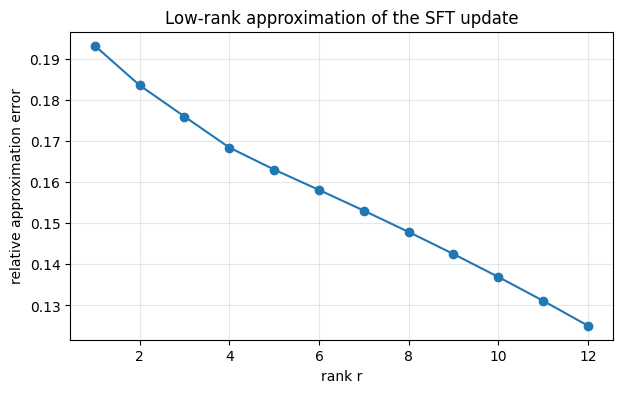

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(param_table["rank"], param_table["relative_Frobenius_error"], marker="o")
plt.xlabel("rank r")
plt.ylabel("relative approximation error")
plt.title("Low-rank approximation of the SFT update")
plt.grid(True, alpha=0.3)
plt.show()

### What this shows

The SFT update $\Delta W$ may be approximated by a low-rank matrix.  In a large Transformer, LoRA inserts trainable low-rank updates into selected weight matrices.  The base model remains fixed, and only the low-rank factors are trained.

## 16. Exercises

Work through these exercises before looking at any solution.

### Exercise 1: Token-level loss

For logits

$$
z=(1.0,0.0,-1.0)
$$

and target class $y=0$, compute the softmax probabilities and cross-entropy loss by hand.  Then verify with Python.

### Exercise 2: Masking

Modify one SFT example so that the prompt is very long.  Show that response-only masking keeps the number of loss tokens focused on the answer.

### Exercise 3: KL movement

Increase `beta_kl` in the KL-regularized SFT section.  What happens to response perplexity and KL movement?

### Exercise 4: Preference loss

Create a new preference example about hallucination.  Compute its DPO-style loss under the fine-tuned model.

### Exercise 5: Low-rank update

Try ranks $r=1,2,3,4,5$.  Which rank gives a reasonable trade-off between parameter count and approximation error?

## 17. AI-assisted learning prompts

Use these prompts with an AI assistant after you have attempted the exercises.

1. **Objective identification**: "Given this training example and mask, identify whether the loss is pretraining, SFT, or preference tuning. Explain the masked positions."
2. **Gradient audit**: "Check my derivation of the softmax cross-entropy gradient. Point out exactly where the chain rule is used."
3. **Alignment comparison**: "Compare SFT, reward modeling, KL-regularized policy optimization, and DPO in terms of data and loss functions."
4. **Implementation review**: "Audit this training loop for common mistakes in padding masks, response masks, and perplexity calculation."
5. **Research reflection**: "Explain why a lower training loss does not automatically imply a safer or more truthful model."

## 18. Mini-project: train and audit a tiny aligned model

Design a small experiment with at least 10 prompt-response examples.

Your report should include:

1. the dataset and vocabulary size;
2. the response-only SFT loss curve;
3. a comparison of SFT with and without KL regularization;
4. at least three inspected next-token distributions;
5. two preference examples and their DPO-style losses;
6. a short discussion of what this toy model can and cannot teach us about real LLM alignment.

A strong report should connect every code output to a mathematical idea from Chapter 18.

## 19. What to remember

Training a language model is not one loss function forever.  It is a sequence of optimization problems:

| Stage | Data | Typical objective |
|---|---|---|
| Pretraining | raw text | next-token cross-entropy |
| Supervised fine-tuning | prompt-response pairs | response-masked cross-entropy |
| Reward modeling | preference comparisons | Bradley--Terry logistic loss |
| RLHF-style tuning | prompts plus rewards | reward improvement with KL control |
| DPO-style tuning | preference pairs | direct preference loss relative to a reference model |
| Parameter-efficient tuning | task data | train only small adapter parameters |

The mathematical building blocks are probability, cross-entropy, masking, optimization, KL divergence, and low-rank linear algebra.